# <span style="color:black;"><strong>Análisis univariado, bivariado, multivariado</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/FCD_U2_1_univariado_bivariado_multivariado.ipynb?clone=true" target="_blank">
  </a>
</p>



# <span style="color:#2F749F;"><strong>Carga del dataset desde Google Drive</strong></span>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

ruta = "/content/drive/MyDrive/Titanic/train.csv"
df = pd.read_csv(ruta)

df.head()

Mounted at /content/drive


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#<strong>Identificación de variables

In [ ]:
df.select_dtypes(include=['int64','float64']).columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

# <span style="color:#2F749F;"><strong>1. Análisis Univariado</strong></span>

#<strong>Variables para el análisis univariado

#Numéricas

- Age

- Fare

- SibSp

- Parch

#Categóricas

- Sex

- Pclass

- Embarked

#Variable objetivo

- Survived

#<strong>Análisis de variables numéricas

## <span style="color:#2F749F;"><strong>1.1. Medidas de Tendencia Central</strong></span>

Cálculo automático de tendencia central para varias variables

In [ ]:
import numpy as np
from scipy import stats

# Variables numéricas relevantes
variables = ['Age','Fare','SibSp','Parch']

resultados = []

for var in variables:

    datos = df[var].dropna()

    media = np.mean(datos)
    mediana = np.median(datos)
    moda = stats.mode(datos, keepdims=True)[0][0]

    resultados.append([var, media, mediana, moda])

tabla_tendencia = pd.DataFrame(resultados, columns=["Variable","Media","Mediana","Moda"])

tabla_tendencia

,Variable,Media,Mediana,Moda
0,Age,29.699118,28.0000,24.00
1,Fare,32.204208,14.4542,8.05
2,SibSp,0.523008,0.0000,0.00
3,Parch,0.381594,0.0000,0.00


Visualización de histogramas para varias variables

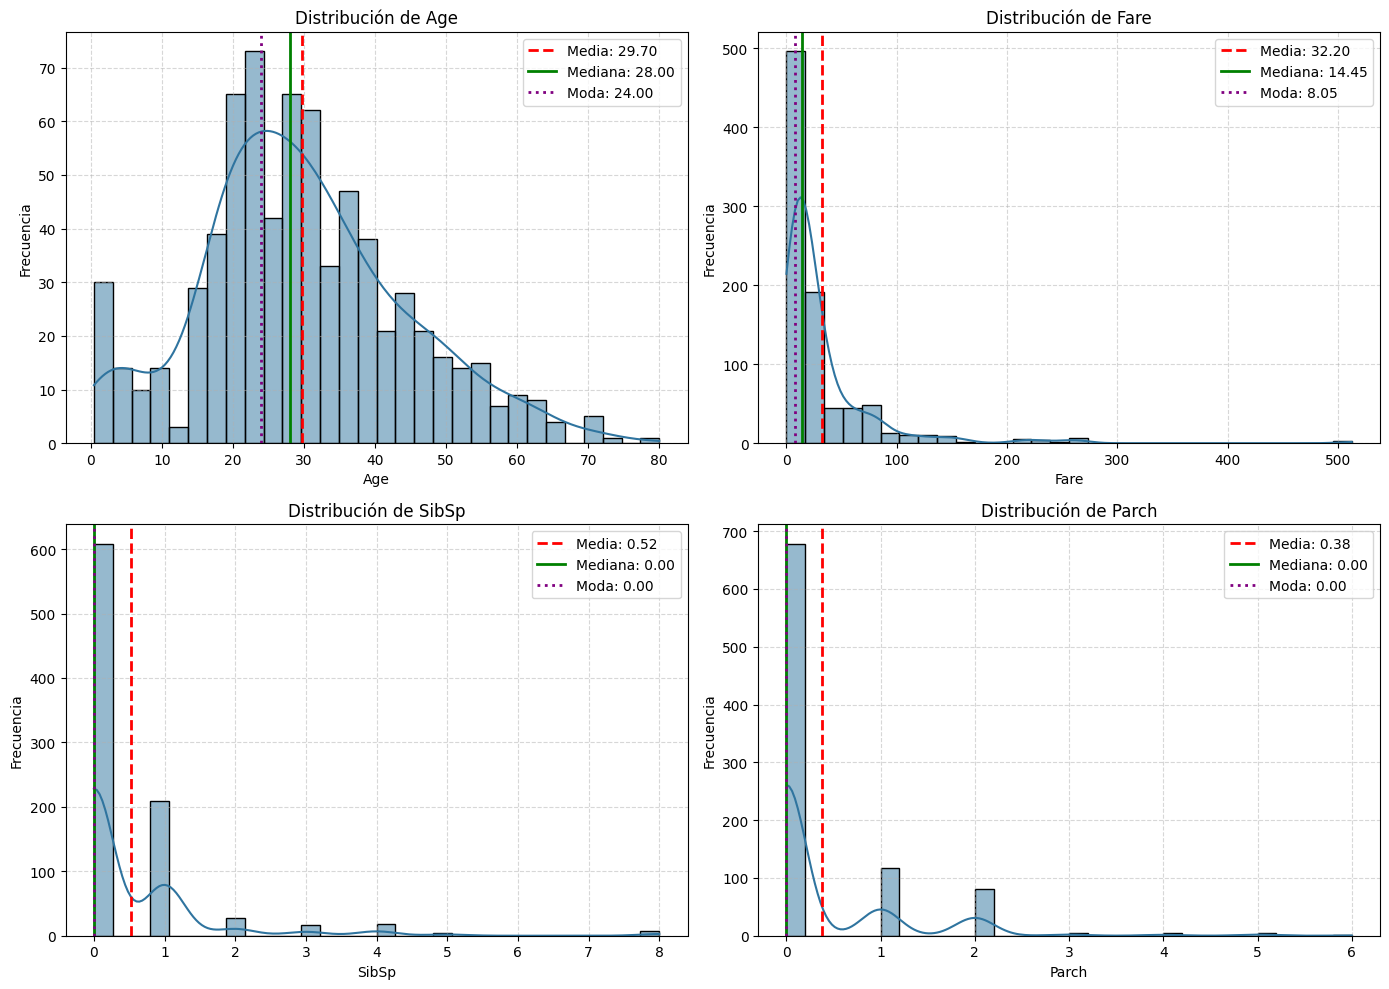

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, var in enumerate(variables):

    datos = df[var].dropna()

    media = datos.mean()
    mediana = datos.median()
    moda = datos.mode()[0]

    sns.histplot(
        datos,
        bins=30,
        kde=True,
        ax=axes[i],
        color="#2F749F"
    )

    axes[i].axvline(media, color='red', linestyle='--', linewidth=2,
                    label=f'Media: {media:.2f}')

    axes[i].axvline(mediana, color='green', linestyle='-',
                    linewidth=2, label=f'Mediana: {mediana:.2f}')

    axes[i].axvline(moda, color='purple', linestyle=':',
                    linewidth=2, label=f'Moda: {moda:.2f}')

    axes[i].set_title(f"Distribución de {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")

    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## <span style="color:#2F749F;"><strong>1.2. Medidas de Dispersión</strong></span>

Tabla de dispersión

In [ ]:
import numpy as np

variables = ['Age','Fare','SibSp','Parch']

resultados_dispersion = []

for var in variables:

    datos = df[var].dropna()

    media = np.mean(datos)
    minimo = np.min(datos)
    maximo = np.max(datos)

    rango = maximo - minimo
    varianza = np.var(datos, ddof=1)
    desviacion = np.std(datos, ddof=1)
    coef_var = desviacion / media

    resultados_dispersion.append([
        var,
        minimo,
        maximo,
        rango,
        varianza,
        desviacion,
        coef_var
    ])

tabla_dispersion = pd.DataFrame(
    resultados_dispersion,
    columns=[
        "Variable",
        "Mínimo",
        "Máximo",
        "Rango",
        "Varianza",
        "Desviación estándar",
        "Coeficiente de variación"
    ]
)

tabla_dispersion

,Variable,Mínimo,Máximo,Rango,Varianza,Desviación estándar,Coeficiente de variación
0,Age,0.42,80.0000,79.5800,211.019125,14.526497,0.489122
1,Fare,0.00,512.3292,512.3292,2469.436846,49.693429,1.543073
2,SibSp,0.00,8.0000,8.0000,1.216043,1.102743,2.108464
3,Parch,0.00,6.0000,6.0000,0.649728,0.806057,2.112344


Visualización de dispersión

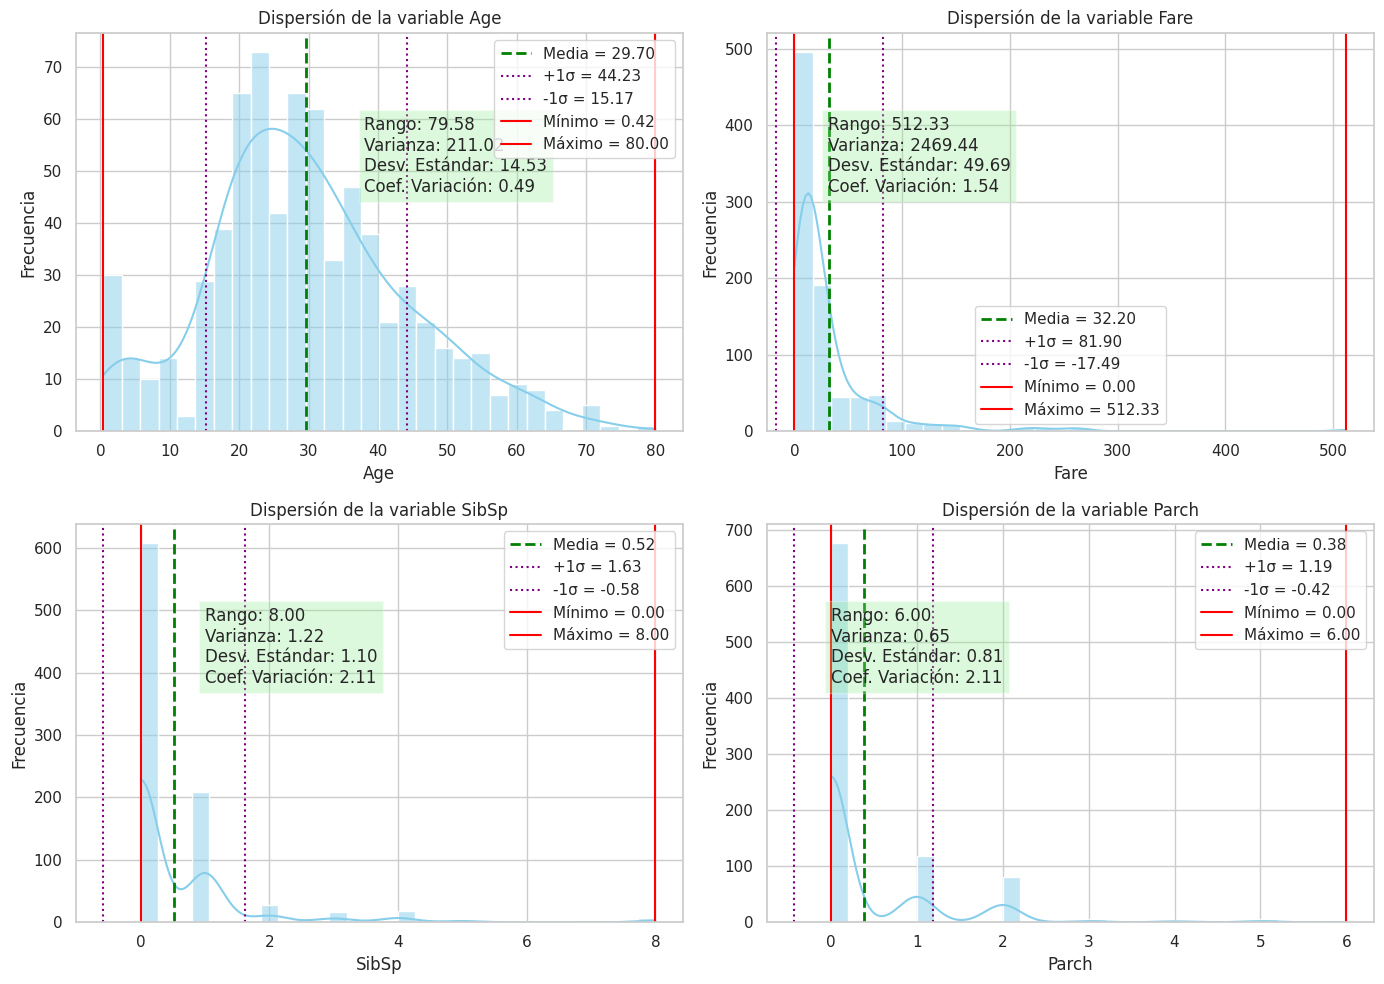

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['Age','Fare','SibSp','Parch']

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, var in enumerate(variables):

    datos = df[var].dropna()

    media = datos.mean()
    minimo = datos.min()
    maximo = datos.max()

    desviacion = datos.std()
    varianza = datos.var()

    rango = maximo - minimo
    coef_var = desviacion / media

    sns.histplot(
        datos,
        bins=30,
        kde=True,
        color="skyblue",
        ax=axes[i]
    )

    axes[i].axvline(media, color='green', linestyle='--', linewidth=2,
                    label=f'Media = {media:.2f}')

    axes[i].axvline(media + desviacion, color='purple', linestyle=':',
                    linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')

    axes[i].axvline(media - desviacion, color='purple', linestyle=':',
                    linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')

    axes[i].axvline(minimo, color='red', linestyle='-',
                    linewidth=1.5, label=f'Mínimo = {minimo:.2f}')

    axes[i].axvline(maximo, color='red', linestyle='-',
                    linewidth=1.5, label=f'Máximo = {maximo:.2f}')

    axes[i].set_title(f"Dispersión de la variable {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")

    texto = (
        f"Rango: {rango:.2f}\n"
        f"Varianza: {varianza:.2f}\n"
        f"Desv. Estándar: {desviacion:.2f}\n"
        f"Coef. Variación: {coef_var:.2f}"
    )

    axes[i].text(
        datos.quantile(0.75),
        axes[i].get_ylim()[1]*0.6,
        texto,
        bbox=dict(facecolor='lightgreen', alpha=0.3)
    )

    axes[i].legend()

plt.tight_layout()
plt.show()

## <span style="color:#2F749F;"><strong>1.3. Distribución</strong></span>

El análisis de distribución permite comprender la forma que tienen los datos, identificando si los valores se concentran alrededor de la media o si presentan asimetrías o colas pronunciadas.

Dos métricas clave para estudiar la forma de una distribución son:

##Asimetría (Skewness)

Indica si la distribución está inclinada hacia la derecha o hacia la izquierda.

skew = 0 → distribución simétrica

skew > 0 → sesgo positivo (cola hacia la derecha)

skew < 0 → sesgo negativo (cola hacia la izquierda)

##Curtosis (Kurtosis)

Mide qué tan concentrados están los datos alrededor de la media.

kurtosis = 0 → distribución normal (mesocúrtica)

kurtosis > 0 → colas pesadas (leptocúrtica)

kurtosis < 0 → colas ligeras (platicúrtica)

In [ ]:
from scipy.stats import skew, kurtosis

variables = ['Age','Fare','SibSp','Parch']

resultados_distribucion = []

for var in variables:

    datos = df[var].dropna()

    asimetria = skew(datos)
    curt = kurtosis(datos, fisher=True)

    resultados_distribucion.append([var, asimetria, curt])

tabla_distribucion = pd.DataFrame(
    resultados_distribucion,
    columns=["Variable","Asimetría (Skewness)","Curtosis"]
)

tabla_distribucion

,Variable,Asimetría (Skewness),Curtosis
0,Age,0.388290,0.168637
1,Fare,4.779253,33.204289
2,SibSp,3.689128,17.773512
3,Parch,2.744487,9.716613


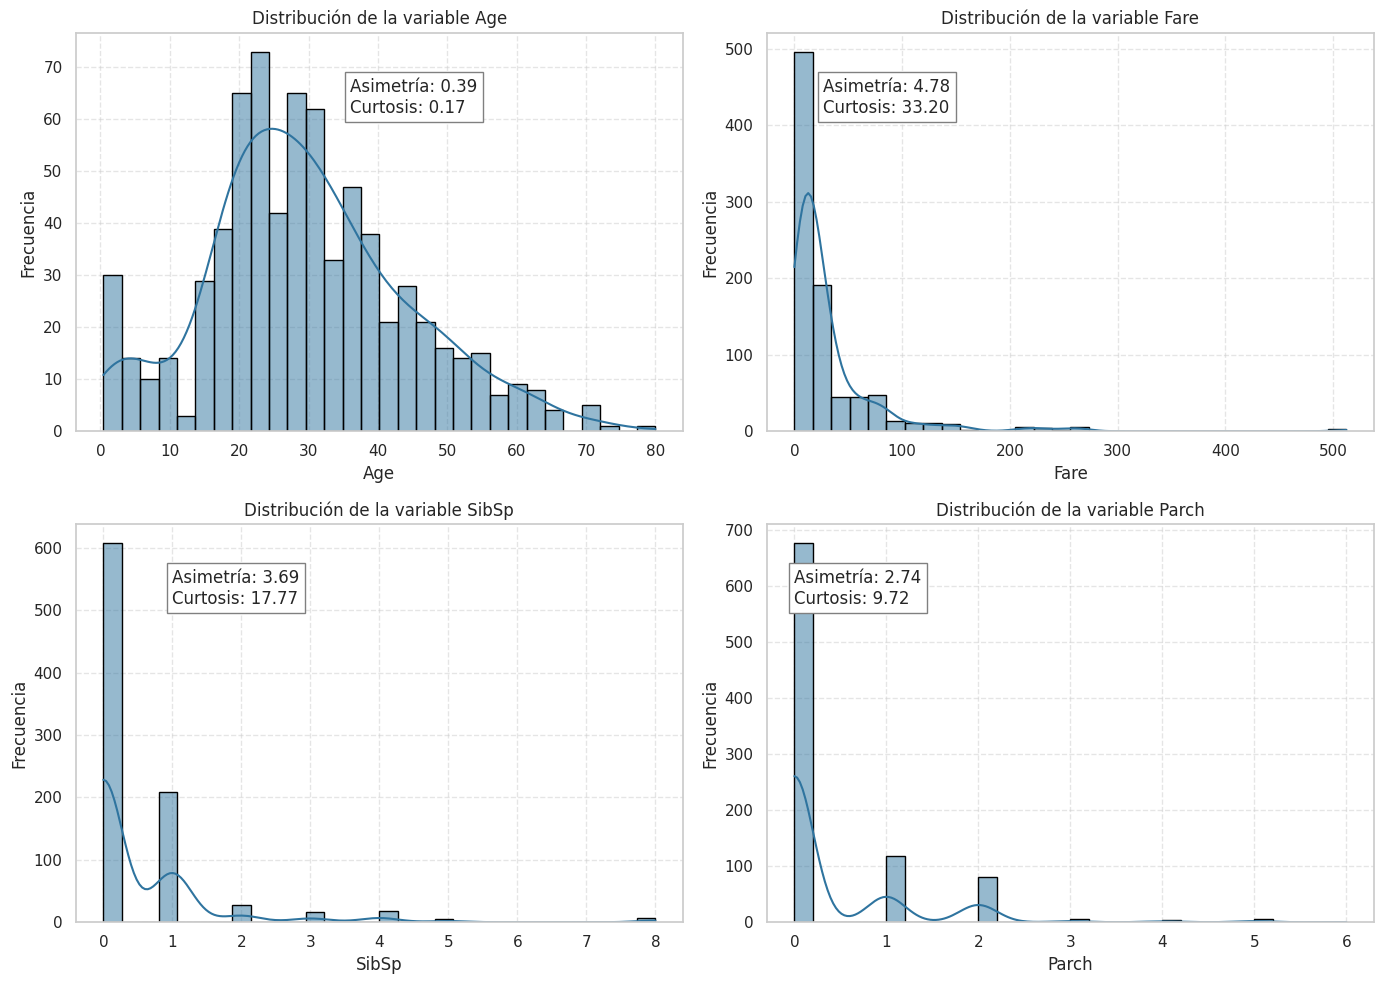

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set_theme(style="whitegrid")

variables = ['Age','Fare','SibSp','Parch']

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, var in enumerate(variables):

    datos = df[var].dropna()

    asimetria = skew(datos)
    curt = kurtosis(datos)

    sns.histplot(
        datos,
        bins=30,
        kde=True,
        color="#2F749F",
        edgecolor="black",
        ax=axes[i]
    )

    axes[i].set_title(f"Distribución de la variable {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")

    texto = (
        f"Asimetría: {asimetria:.2f}\n"
        f"Curtosis: {curt:.2f}"
    )

    axes[i].text(
        datos.quantile(0.70),
        axes[i].get_ylim()[1]*0.8,
        texto,
        bbox=dict(facecolor="white", edgecolor="gray")
    )

    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

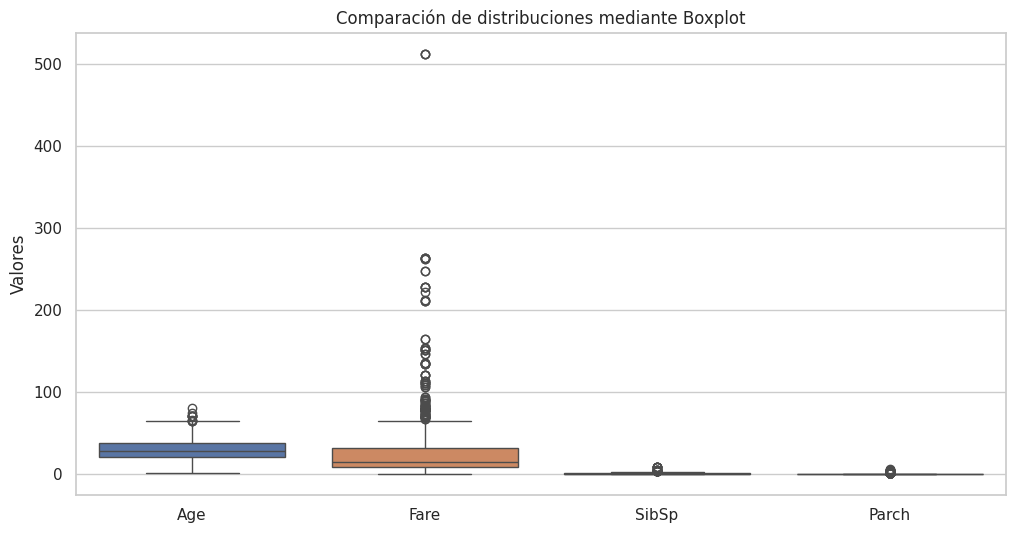

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[['Age','Fare','SibSp','Parch']])

plt.title("Comparación de distribuciones mediante Boxplot")
plt.ylabel("Valores")

plt.show()

## <span style="color:#2F749F;"><strong>1.4. Percentiles</strong></span>

In [ ]:
variables = ['Age','Fare','SibSp','Parch']

resultados_percentiles = []

for var in variables:

    datos = df[var].dropna()

    p10 = np.percentile(datos, 10)
    q1 = np.percentile(datos, 25)
    mediana = np.percentile(datos, 50)
    q3 = np.percentile(datos, 75)
    p90 = np.percentile(datos, 90)

    iqr = q3 - q1

    resultados_percentiles.append([
        var,
        p10,
        q1,
        mediana,
        q3,
        p90,
        iqr
    ])

tabla_percentiles = pd.DataFrame(
    resultados_percentiles,
    columns=[
        "Variable",
        "P10",
        "Q1 (P25)",
        "Mediana (P50)",
        "Q3 (P75)",
        "P90",
        "IQR"
    ]
)

tabla_percentiles

,Variable,P10,Q1 (P25),Mediana (P50),Q3 (P75),P90,IQR
0,Age,14.00,20.1250,28.0000,38.0,50.0000,17.8750
1,Fare,7.55,7.9104,14.4542,31.0,77.9583,23.0896
2,SibSp,0.00,0.0000,0.0000,1.0,1.0000,1.0000
3,Parch,0.00,0.0000,0.0000,0.0,2.0000,0.0000


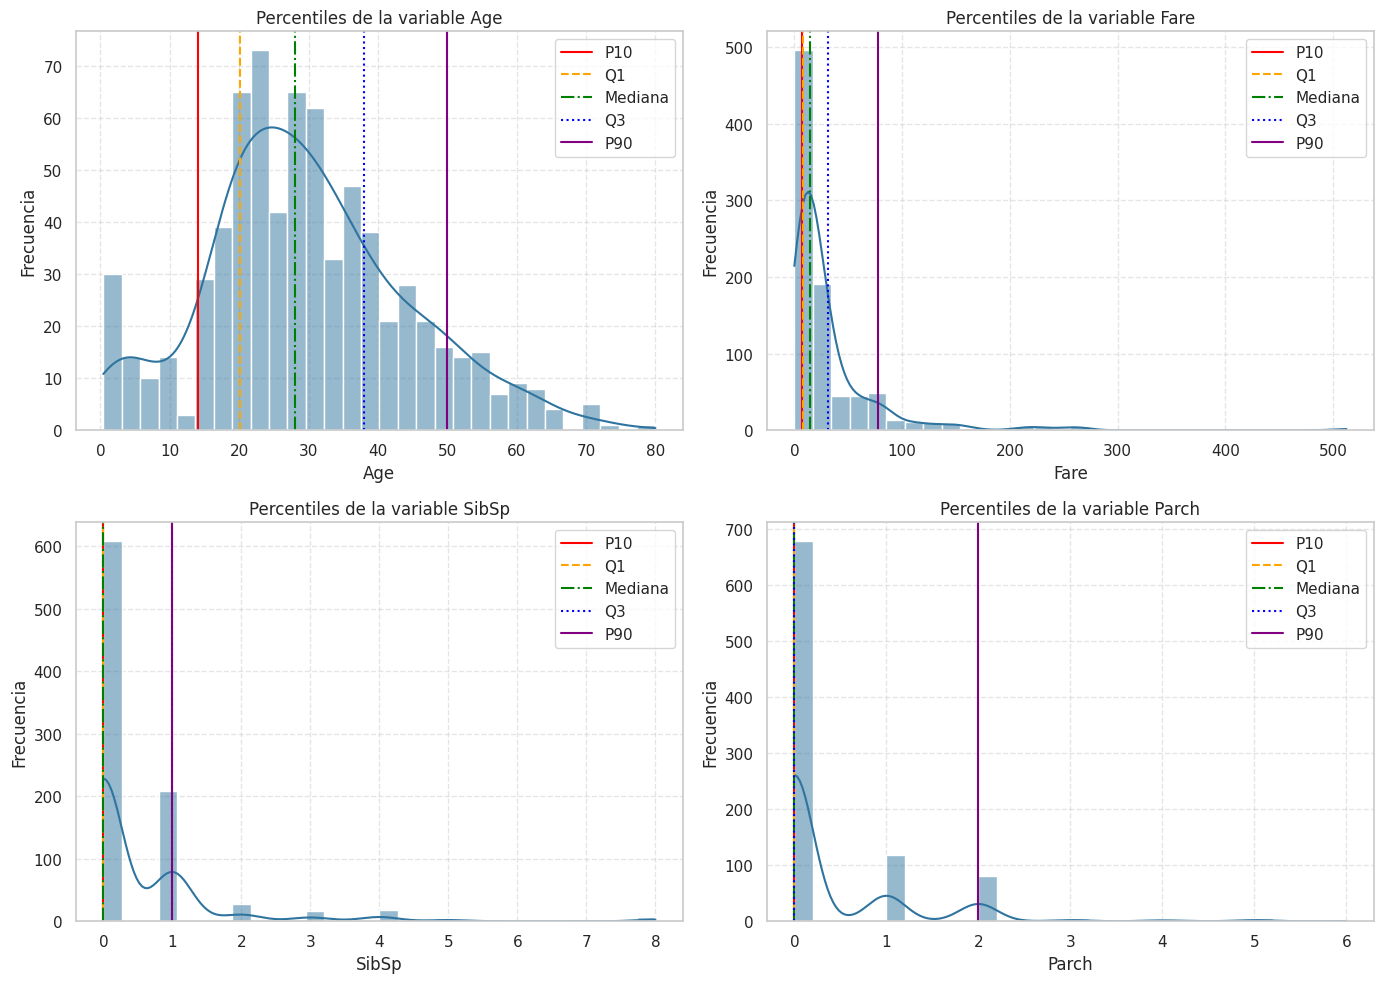

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

variables = ['Age','Fare','SibSp','Parch']

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, var in enumerate(variables):

    datos = df[var].dropna()

    p10 = np.percentile(datos, 10)
    q1 = np.percentile(datos, 25)
    p50 = np.percentile(datos, 50)
    q3 = np.percentile(datos, 75)
    p90 = np.percentile(datos, 90)

    sns.histplot(
        datos,
        bins=30,
        kde=True,
        color="#2F749F",
        ax=axes[i]
    )

    axes[i].axvline(p10, color='red', linestyle='-', label="P10")
    axes[i].axvline(q1, color='orange', linestyle='--', label="Q1")
    axes[i].axvline(p50, color='green', linestyle='-.', label="Mediana")
    axes[i].axvline(q3, color='blue', linestyle=':', label="Q3")
    axes[i].axvline(p90, color='purple', linestyle='-', label="P90")

    axes[i].set_title(f"Percentiles de la variable {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")

    axes[i].legend()
    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [ ]:
variables = ['Age','Fare','SibSp','Parch']

for var in variables:

    datos = df[var].dropna()

    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = datos[(datos < limite_inferior) | (datos > limite_superior)]

    print(f"\nVariable: {var}")
    print(f"IQR: {iqr:.2f}")
    print(f"Outliers detectados: {len(outliers)}")


Variable: Age
IQR: 17.88
Outliers detectados: 11

Variable: Fare
IQR: 23.09
Outliers detectados: 116

Variable: SibSp
IQR: 1.00
Outliers detectados: 46

Variable: Parch
IQR: 0.00
Outliers detectados: 213


#<strong>Análisis de variables Categóricas

## <span style="color:#2F749F;"><strong>1.5. Tabla de frecuencias</strong></span>

In [ ]:
variables_cat = ["Sex", "Pclass", "Embarked"]

for var in variables_cat:

    print("\nVariable:", var)

    tabla = df[var].value_counts()
    porcentaje = df[var].value_counts(normalize=True) * 100

    resumen = pd.DataFrame({
        "Frecuencia": tabla,
        "Porcentaje (%)": porcentaje
    })

    print(resumen.round(2))


Variable: Sex
        Frecuencia  Porcentaje (%)
Sex                               
male           577           64.76
female         314           35.24

Variable: Pclass
        Frecuencia  Porcentaje (%)
Pclass                            
3              491           55.11
1              216           24.24
2              184           20.65

Variable: Embarked
          Frecuencia  Porcentaje (%)
Embarked                            
S                644           72.44
C                168           18.90
Q                 77            8.66


## <span style="color:#2F749F;"><strong>1.6. Gráfico de proporciones</strong></span>

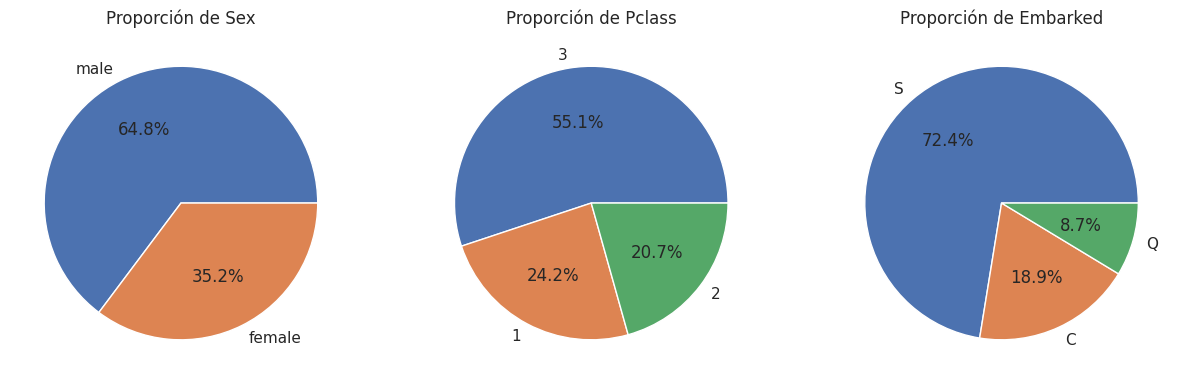

In [ ]:
variables_cat = ["Sex", "Pclass", "Embarked"]

fig, axes = plt.subplots(1,3, figsize=(15,5))

for i, var in enumerate(variables_cat):

    proporciones = df[var].value_counts(normalize=True)

    axes[i].pie(
        proporciones,
        labels=proporciones.index,
        autopct="%1.1f%%"
    )

    axes[i].set_title(f"Proporción de {var}")

plt.show()

## <span style="color:#2F749F;"><strong>Resultados del análisis univariado</strong></span>

#Variable Age

El histograma muestra una concentración entre los 20 y 40 años con una cola hacia la derecha, lo que significa que la distribución presenta una ligera asimetría positiva, indicando la presencia de algunos pasajeros de mayor edad, aunque en menor proporción.

La media de edad de los pasajeros es aproximadamente de 29.7 años, mientras que la mediana es cercana a 28 años, lo cual sugiere una distribución relativamente equilibrada con una ligera influencia de valores altos.

Con el análisis de percentiles se observa que el 50% de los pasajeros tiene edades entre aproximadamente 20 y 38 años, lo que confirma la concentración en adultos jóvenes.

En el Boxplot se observan algunos valores atípicos correspondientes a pasajeros de edad avanzada, superiores a los 65 años.

#Variable Fare

La variable Fare presenta una fuerte asimetría positiva, con una alta concentración de tarifas bajas y algunos valores extremadamente altos.

La media es de aproximadamente 32, la cual es considerablemente mayor que la mediana, cuyo valor es de aproximadamente 14, lo cual confirma la presencia de valores extremos que elevan el promedio.

Esto es una interpretación estadística correcta.

En los percentiles se observa que el 75% de los pasajeros pagó menos de aproximadamente 31 unidades monetarias, mientras que solo el 10% pagó más de aproximadamente 77, lo que refleja una fuerte desigualdad en las tarifas.

En el Boxplot, la variable presenta numerosos valores atípicos asociados a tarifas muy elevadas, probablemente correspondientes a pasajeros de primera clase.

#Variables SibSp y Parch

En el análisis se observa que ambas variables son discretas, presentan alta concentración en el valor 0, tienen poca dispersión y los valores altos son poco frecuentes, lo que indica que la mayoría de los pasajeros viajaba sin hermanos, cónyuge, padres o hijos a bordo.

Estas variables aportan información limitada en el análisis univariado, pero pueden resultar relevantes cuando se analizan en conjunto con otras variables o cuando se utilizan para construir indicadores relacionados con la estructura familiar de los pasajeros.

#Variables categóricas

La mayoría de los pasajeros del Titanic eran hombres, representando aproximadamente el 65% de la muestra, mientras que las mujeres corresponden aproximadamente al 35%. Más de la mitad de los pasajeros pertenecían a la tercera clase, lo que refleja la fuerte presencia de pasajeros de clase económica en el viaje. Y la mayoría de los pasajeros embarcó en Southampton, seguido por Cherbourg y Queenstown.

# <span style="color:#2F749F;"><strong>2. Análisis Bivariado</strong></span>

## **Coeficiente de correlación de Pearson.**

In [ ]:
from scipy.stats import pearsonr
import pandas as pd

variables = ["Age","Fare","SibSp","Parch"]

resultados = []

for i in range(len(variables)):
    for j in range(i+1, len(variables)):

        var1 = variables[i]
        var2 = variables[j]

        df_temp = df[[var1,var2]].dropna()

        r, p = pearsonr(df_temp[var1], df_temp[var2])

        resultados.append({
            "Variable 1": var1,
            "Variable 2": var2,
            "Pearson r": r,
            "p-value": p
        })

tabla_corr = pd.DataFrame(resultados)

print(tabla_corr)

  Variable 1 Variable 2  Pearson r       p-value
0        Age       Fare   0.096067  1.021628e-02
1        Age      SibSp  -0.308247  3.509025e-17
2        Age      Parch  -0.189119  3.569949e-07
3       Fare      SibSp   0.159651  1.671256e-06
4       Fare      Parch   0.216225  6.915292e-11
5      SibSp      Parch   0.414838  2.241824e-38


## **Coeficiente de correlación de Spearman**

In [ ]:
from scipy.stats import spearmanr
import pandas as pd

variables = ["Age","Fare","SibSp","Parch"]

resultados = []

for i in range(len(variables)):
    for j in range(i+1, len(variables)):

        var1 = variables[i]
        var2 = variables[j]

        df_temp = df[[var1,var2]].dropna()

        rho, p = spearmanr(df_temp[var1], df_temp[var2])

        resultados.append({
            "Variable 1": var1,
            "Variable 2": var2,
            "Spearman ρ": rho,
            "p-value": p
        })

tabla_spearman = pd.DataFrame(resultados)

print(tabla_spearman)

  Variable 1 Variable 2  Spearman ρ       p-value
0        Age       Fare    0.135051  2.958090e-04
1        Age      SibSp   -0.182061  9.717194e-07
2        Age      Parch   -0.254212  5.408557e-12
3       Fare      SibSp    0.447113  5.250854e-45
4       Fare      Parch    0.410074  1.860780e-37
5      SibSp      Parch    0.450014  1.226002e-45


<b>Pearson vs Spearman</b>

In [ ]:
from scipy.stats import pearsonr, spearmanr

variables = ["Age","Fare","SibSp","Parch"]

resultados = []

for i in range(len(variables)):
    for j in range(i+1, len(variables)):

        var1 = variables[i]
        var2 = variables[j]

        df_temp = df[[var1,var2]].dropna()

        pearson, _ = pearsonr(df_temp[var1], df_temp[var2])
        spearman, _ = spearmanr(df_temp[var1], df_temp[var2])

        resultados.append({
            "Variable 1": var1,
            "Variable 2": var2,
            "Pearson": pearson,
            "Spearman": spearman
        })

tabla_corr = pd.DataFrame(resultados)

print(tabla_corr.round(3))

  Variable 1 Variable 2  Pearson  Spearman
0        Age       Fare    0.096     0.135
1        Age      SibSp   -0.308    -0.182
2        Age      Parch   -0.189    -0.254
3       Fare      SibSp    0.160     0.447
4       Fare      Parch    0.216     0.410
5      SibSp      Parch    0.415     0.450


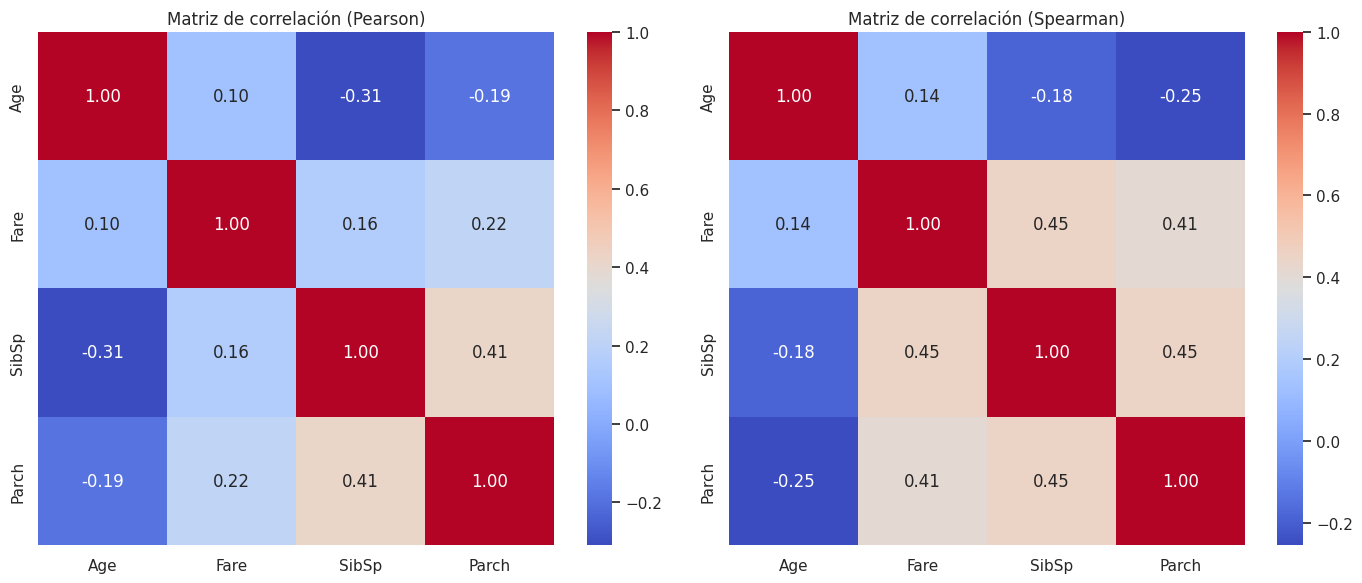

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

variables = ["Age","Fare","SibSp","Parch"]

pearson_corr = df[variables].corr(method="pearson")
spearman_corr = df[variables].corr(method="spearman")

fig, axes = plt.subplots(1,2, figsize=(14,6))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[0]
)

axes[0].set_title("Matriz de correlación (Pearson)")

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[1]
)

axes[1].set_title("Matriz de correlación (Spearman)")

plt.tight_layout()
plt.show()

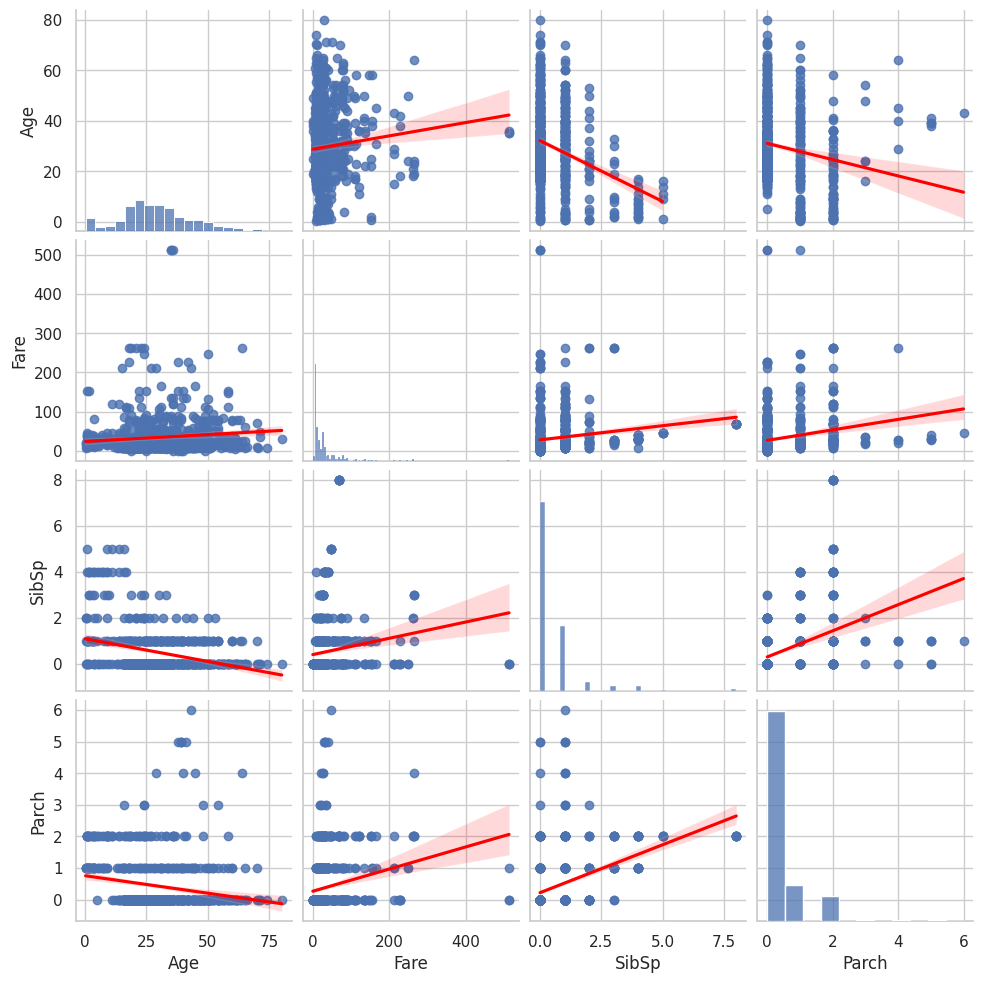

In [ ]:
sns.pairplot(
    df[["Age","Fare","SibSp","Parch"]],
    kind="reg",
    plot_kws={"line_kws":{"color":"red"}}
)

plt.show()

## **Chi-cuadrado de independencia**

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

resultados = []

variables = ["Sex", "Pclass", "Embarked"]

for var in variables:

    tabla = pd.crosstab(df[var], df["Survived"])

    chi2, p, dof, expected = chi2_contingency(tabla)

    n = tabla.sum().sum()
    min_dim = min(tabla.shape) - 1

    cramer_v = np.sqrt(chi2 / (n * min_dim))

    resultados.append({
        "Variable": var,
        "Chi2": chi2,
        "p-value": p,
        "GL": dof,
        "Cramers_V": cramer_v
    })

tabla_resultados = pd.DataFrame(resultados)

# Interpretación automática
def interpretar(v):
    if v < 0.1:
        return "Asociación muy débil"
    elif v < 0.3:
        return "Asociación débil"
    elif v < 0.5:
        return "Asociación moderada"
    else:
        return "Asociación fuerte"

tabla_resultados["Interpretación"] = tabla_resultados["Cramers_V"].apply(interpretar)

print(tabla_resultados.round(4))

   Variable      Chi2  p-value  GL  Cramers_V       Interpretación
0       Sex  260.7170      0.0   1     0.5409    Asociación fuerte
1    Pclass  102.8890      0.0   2     0.3398  Asociación moderada
2  Embarked   26.4891      0.0   2     0.1726     Asociación débil


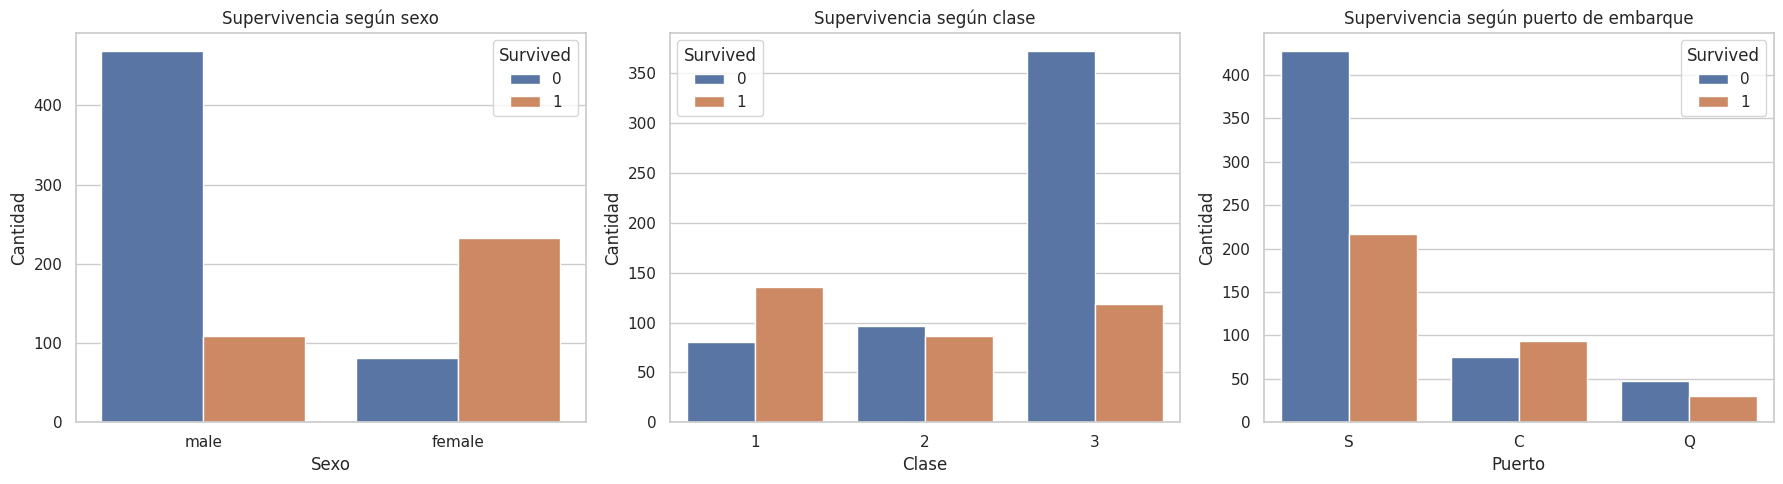

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Sex vs Survived
sns.countplot(
    x="Sex",
    hue="Survived",
    data=df,
    ax=axes[0]
)

axes[0].set_title("Supervivencia según sexo")
axes[0].set_xlabel("Sexo")
axes[0].set_ylabel("Cantidad")

# Pclass vs Survived
sns.countplot(
    x="Pclass",
    hue="Survived",
    data=df,
    ax=axes[1]
)

axes[1].set_title("Supervivencia según clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Cantidad")

# Embarked vs Survived
sns.countplot(
    x="Embarked",
    hue="Survived",
    data=df,
    ax=axes[2]
)

axes[2].set_title("Supervivencia según puerto de embarque")
axes[2].set_xlabel("Puerto")
axes[2].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

## <span style="color:#2F749F;"><strong>Resultados del análisis bivariado</strong></span>

#Correlación de Pearson
Se observa una correlación negativa moderada entre Age y SibSp, una correlación positiva moderada entre SibSp y Parch, las otras correlaciones son débiles. Esto indica que los pasajeros jóvenes viajaban más con familiares.

#Correlación de Spearman
Valores similares a los obtenidos con Pearson, pero un poco más altos:

SibSp vs Parch = 0.45

Fare vs SibSp = 0.45

#Age vs Fare
Los pasajeros de mayor edad tienden a pagar tarifas ligeramente más altas, aunque la dispersión de los datos es elevada, por lo que la relación observada es débil.

#Age vs SibSp
A medida que aumenta la edad del pasajero, el número de hermanos o cónyuges a bordo tiende a disminuir.

#Age vs Parch
Los pasajeros de mayor edad presentan, en promedio, un menor número de padres o hijos a bordo.

#Fare vs SibSp / Fare vs Parch
Los pasajeros que viajan acompañados por familiares tienden a registrar tarifas ligeramente mayores. Pero la dispersión indica que la relación es débil.

#Test Chi-cuadrado
Existe evidencia estadística de asociación entre el sexo del pasajero y la supervivencia.

Se observa una asociación entre la clase del pasajero y la supervivencia.

No se observa evidencia suficiente para afirmar una asociación fuerte entre el puerto de embarque y la supervivencia.

